In [1]:
import pathlib
import sys

import networkx as nx
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import patches as mpatches
from vizopt.templates import nested_circles

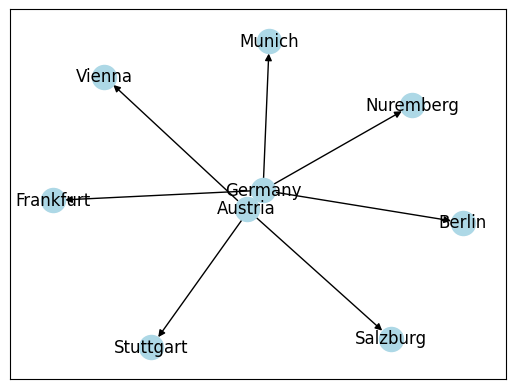

In [2]:
# Example: Single inclusion tree with leaf nodes (cities) and non-leaf nodes (countries)
# Leaf nodes have fixed "size" attributes, non-leaf nodes have optimizable radii

inclusion_tree = nx.DiGraph()

# Add leaf nodes (cities) with fixed sizes
cities = {
    "Munich": 10,
    "Berlin": 25,
    "Stuttgart": 5,
    "Frankfurt": 5,
    "Nuremberg": 3,
    "Vienna": 15,
    "Salzburg": 5,
}

for city, size in cities.items():
    inclusion_tree.add_node(city, size=size)

# Add non-leaf nodes (countries) - these will have optimizable radii
inclusion_tree.add_node("Germany")
inclusion_tree.add_node("Austria")

# Define containment relationships: (parent, child) means child is contained in parent
inclusion_tree.add_edges_from([
    ("Germany", "Munich"),
    ("Germany", "Berlin"),
    ("Germany", "Stuttgart"),
    ("Germany", "Frankfurt"),
    ("Germany", "Nuremberg"),
    ("Austria", "Vienna"),
    ("Austria", "Salzburg"),
])

# Visualize the tree structure
nx.draw_networkx(inclusion_tree, with_labels=True, node_color='lightblue', 
                 arrows=True, pos=nx.spring_layout(inclusion_tree, seed=42))

Iteration 0: loss = 31207.0546875
Iteration 100: loss = 16247.2734375
Iteration 200: loss = 9986.2890625
Iteration 300: loss = 4151.947265625
Iteration 400: loss = 1111.7425537109375
Iteration 500: loss = 414.879638671875
Iteration 600: loss = 411.7249755859375
Iteration 700: loss = 408.9586181640625
Iteration 800: loss = 406.0084228515625
Iteration 900: loss = 405.13836669921875
Iteration 1000: loss = 403.5240783691406
Iteration 1100: loss = 401.76397705078125
Iteration 1200: loss = 401.5899658203125
Iteration 1300: loss = 401.56494140625
Iteration 1400: loss = 404.0021667480469
Iteration 1500: loss = 401.49090576171875
Iteration 1600: loss = 404.0722961425781
Iteration 1700: loss = 400.9359436035156
Iteration 1800: loss = 400.7757263183594
Iteration 1900: loss = 401.7711486816406
Iteration 2000: loss = 401.869873046875
Iteration 2100: loss = 402.12750244140625
Iteration 2200: loss = 401.5852355957031
Iteration 2300: loss = 401.3485412597656
Iteration 2400: loss = 402.63092041015625
I

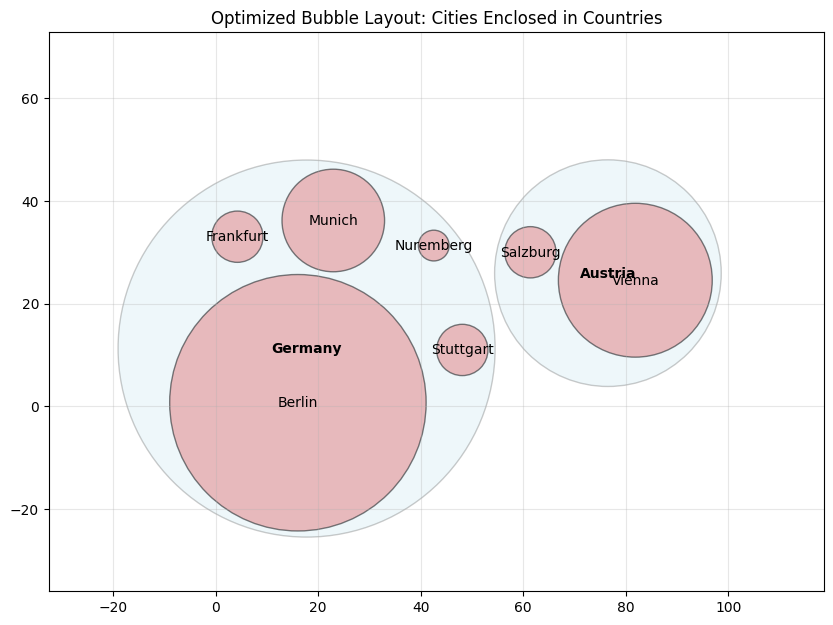

In [3]:
# Optimize the layout using the new function
pos, non_leaf_radii = nested_circles.optimize_circular_layout_with_enclosed_nodes(
    inclusion_tree=inclusion_tree,
    optim_kwargs={"n_iters": 10000, "learning_rate": 1*1e-1}
)

# Visualize the optimized layout
_, ax = plt.subplots(figsize=(10, 10))

# Draw all nodes as circles
for node, node_xy in pos.items():
    # Determine radius: leaf nodes use their "size" attribute, non-leaf use optimized radii
    if inclusion_tree.out_degree(node) == 0:  # leaf node
        radius = inclusion_tree.nodes[node]["size"]
        color = 'lightcoral'  # cities in red
        alpha = 0.6
    else:  # non-leaf node
        radius = non_leaf_radii[node]
        color = 'lightblue'  # countries in blue
        alpha = 0.2
    
    circle = mpatches.Circle(node_xy, radius=radius, color=color, alpha=alpha, ec='black', linewidth=1)
    ax.add_patch(circle)
    ax.text(node_xy[0], node_xy[1], node, color="k", ha="center", va="center", 
            fontsize=10, weight='bold' if inclusion_tree.out_degree(node) > 0 else 'normal')

# Set axis limits
max_radius = max(non_leaf_radii.values())
xmin = min(pos[node][0] - max_radius for node in pos)
xmax = max(pos[node][0] + max_radius for node in pos)
ymin = min(pos[node][1] - max_radius for node in pos)
ymax = max(pos[node][1] + max_radius for node in pos)
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_aspect("equal")
ax.set_title("Optimized Bubble Layout: Cities Enclosed in Countries")
ax.grid(True, alpha=0.3)

print(f"Optimized radii for non-leaf nodes: {non_leaf_radii}")

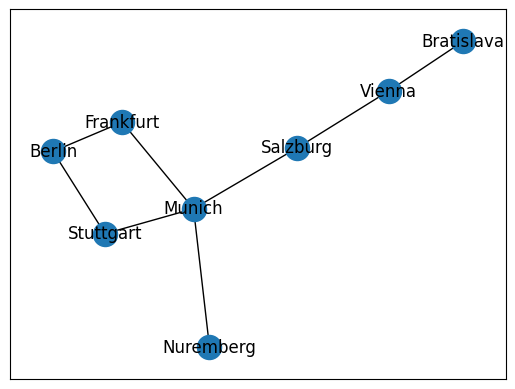

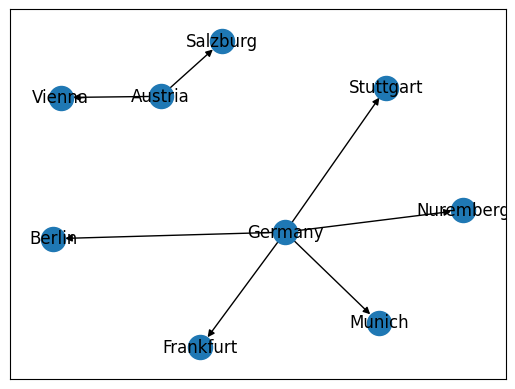

In [4]:
main_graph = nx.Graph()
main_graph.add_node("Munich", size=10)
main_graph.add_node("Frankfurt", size=5)
main_graph.add_node("Nuremberg", size=3)
main_graph.add_node("Berlin", size=25)
main_graph.add_node("Stuttgart", size=5)
main_graph.add_node("Salzburg", size=5)
main_graph.add_node("Vienna", size=15)
main_graph.add_edges_from([("Munich", "Frankfurt"), ("Munich", "Nuremberg"), ("Frankfurt", "Berlin")])
main_graph.add_edges_from([("Munich", "Stuttgart"), ("Stuttgart", "Berlin")])
main_graph.add_edges_from([("Munich", "Salzburg"), ("Salzburg", "Vienna")])
main_graph.add_edges_from([("Bratislava", "Vienna")])

n_add_nodes = 0
for i_node in range(1, n_add_nodes+1):
    main_graph.add_node(f"Node{i_node}", size=5)
    main_graph.add_edges_from([("Node"+str(i_node), "Munich")])


nx.draw_networkx(main_graph)

_, ax = plt.subplots()
nx.draw_networkx(inclusion_tree)

In [5]:
pos, enclosing_node_radius_dict = nested_circles.optimize_circular_layout_with_enclosed_and_linked_nodes(graph=main_graph, inclusion_tree=inclusion_tree,
                                                         optim_kwargs={"n_iters": 10000, "learning_rate": 5*1e-1})
pos

node Bratislava has no size
Iteration 0: loss = 29260.462890625
Iteration 100: loss = 8018.5185546875
Iteration 200: loss = 743.6932983398438
Iteration 300: loss = 711.1235961914062
Iteration 400: loss = 692.0929565429688
Iteration 500: loss = 687.5435180664062
Iteration 600: loss = 667.38427734375
Iteration 700: loss = 667.8485107421875
Iteration 800: loss = 665.6646728515625
Iteration 900: loss = 661.7119140625
Iteration 1000: loss = 656.3636474609375
Iteration 1100: loss = 663.4420166015625
Iteration 1200: loss = 661.8867797851562
Iteration 1300: loss = 657.8489990234375
Iteration 1400: loss = 649.0128173828125
Iteration 1500: loss = 658.7078857421875
Iteration 1600: loss = 652.1574096679688
Iteration 1700: loss = 660.24658203125
Iteration 1800: loss = 652.6776123046875
Iteration 1900: loss = 629.8929443359375
Iteration 2000: loss = 629.4612426757812
Iteration 2100: loss = 641.3805541992188
Iteration 2200: loss = 640.1832275390625
Iteration 2300: loss = 630.2891235351562
Iteration 2

{'Munich': (43.5488166809082, 36.40510559082031),
 'Frankfurt': (49.85495376586914, 17.843828201293945),
 'Nuremberg': (39.37819290161133, 20.87670135498047),
 'Berlin': (80.2111587524414, 29.607135772705078),
 'Stuttgart': (53.69614028930664, 6.408686637878418),
 'Salzburg': (22.45421600341797, 39.57716751098633),
 'Vienna': (1.6437678337097168, 43.582008361816406),
 'Bratislava': (19.862770080566406, 68.4891357421875),
 'Austria': (5.634268283843994, 42.87651062011719),
 'Germany': (70.09005737304688, 31.216650009155273)}

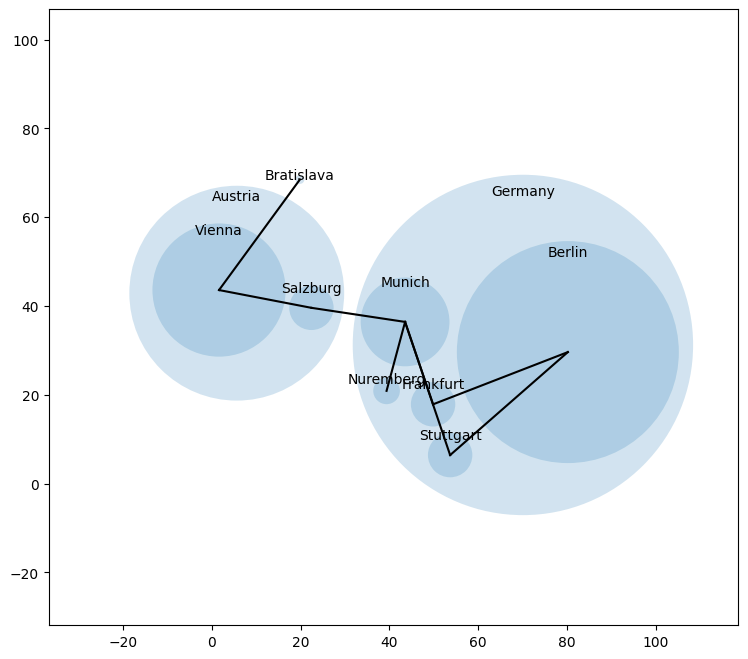

In [6]:
_, ax = plt.subplots(figsize=(9, 8))

for node, node_xy in pos.items():
    if node in main_graph.nodes:
        if "size" in main_graph.nodes[node]:
            radius = main_graph.nodes[node]["size"]
        else:
            radius = 1.0
    else:
        radius = enclosing_node_radius_dict[node]
    circle = mpatches.Circle(node_xy, radius=radius, alpha=0.2)
    ax.add_patch(circle)
    ax.text(node_xy[0], node_xy[1] + 0.9*radius, node, color="k", ha="center", va="center")
for edge in main_graph.edges:
    ax.plot(
        [pos[edge[0]][0], pos[edge[1]][0]],
        [pos[edge[0]][1], pos[edge[1]][1]],
        "k-",
    )
max_node_size = max(main_graph.nodes[node]["size"] for node in main_graph.nodes if "size" in main_graph.nodes[node])
max_node_size = max(enclosing_node_radius_dict.values())
xmin = min(pos[node][0] - max_node_size for node in pos)
xmax = max(pos[node][0] + max_node_size for node in pos)
ymin = min(pos[node][1] - max_node_size for node in pos)
ymax = max(pos[node][1] + max_node_size for node in pos)
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
# equal axes
ax.set_aspect("equal")

In [7]:
inclusion_tree.add_edges_from([("Europe", "Germany"), ("Europe", "Austria")])
inclusion_tree.edges

OutEdgeView([('Germany', 'Munich'), ('Germany', 'Berlin'), ('Germany', 'Stuttgart'), ('Germany', 'Frankfurt'), ('Germany', 'Nuremberg'), ('Austria', 'Vienna'), ('Austria', 'Salzburg'), ('Europe', 'Germany'), ('Europe', 'Austria')])

## Scaling experiment

In [8]:
n_bubbles = 100

In [9]:
def make_random_forest(n_bubbles, n_trees=None, seed=42):
    """Create a random inclusion tree (forest) with n_bubbles leaf nodes.

    Args:
        n_bubbles: Total number of leaf (bubble) nodes.
        n_trees: Number of enclosing groups. Defaults to max(1, n_bubbles // 8).
        seed: Random seed for reproducibility.

    Returns:
        NetworkX DiGraph where each edge (root, leaf) means leaf is inside root.
    """
    rng = np.random.default_rng(seed)
    n_trees = n_trees or max(1, n_bubbles // 8)

    tree = nx.DiGraph()
    roots = [f"Group{i}" for i in range(n_trees)]
    for root in roots:
        tree.add_node(root)

    # Assign each bubble to a random group
    assignments = rng.integers(0, n_trees, size=n_bubbles)
    scale = 10.
    for i in range(n_bubbles):
        #size = float(rng.integers(3, 20))
        size = float(rng.uniform(scale*3, scale*20))
        name = f"Bubble{i}"
        tree.add_node(name, size=size)
        tree.add_edge(roots[assignments[i]], name)

    return tree


100 bubbles across 12 groups
Iteration 0: loss = 54205100.0
Iteration 100: loss = 54109540.0
Iteration 200: loss = 54014464.0
Iteration 300: loss = 53919520.0
Iteration 400: loss = 53824540.0
Iteration 500: loss = 53729512.0
Iteration 600: loss = 53634432.0
Iteration 700: loss = 53539324.0
Iteration 800: loss = 53444212.0
Iteration 900: loss = 53349060.0
Iteration 1000: loss = 53253896.0
Iteration 1100: loss = 53158716.0
Iteration 1200: loss = 53063824.0
Iteration 1300: loss = 52969104.0
Iteration 1400: loss = 52874512.0
Iteration 1500: loss = 52780432.0
Iteration 1600: loss = 52686412.0
Iteration 1700: loss = 52593600.0
Iteration 1800: loss = 52501028.0
Iteration 1900: loss = 52408580.0
Iteration 2000: loss = 52316144.0
Iteration 2100: loss = 52223704.0
Iteration 2200: loss = 52131248.0
Iteration 2300: loss = 52038840.0
Iteration 2400: loss = 51946812.0
Iteration 2500: loss = 51854828.0
Iteration 2600: loss = 51763160.0
Iteration 2700: loss = 51671508.0
Iteration 2800: loss = 51579864

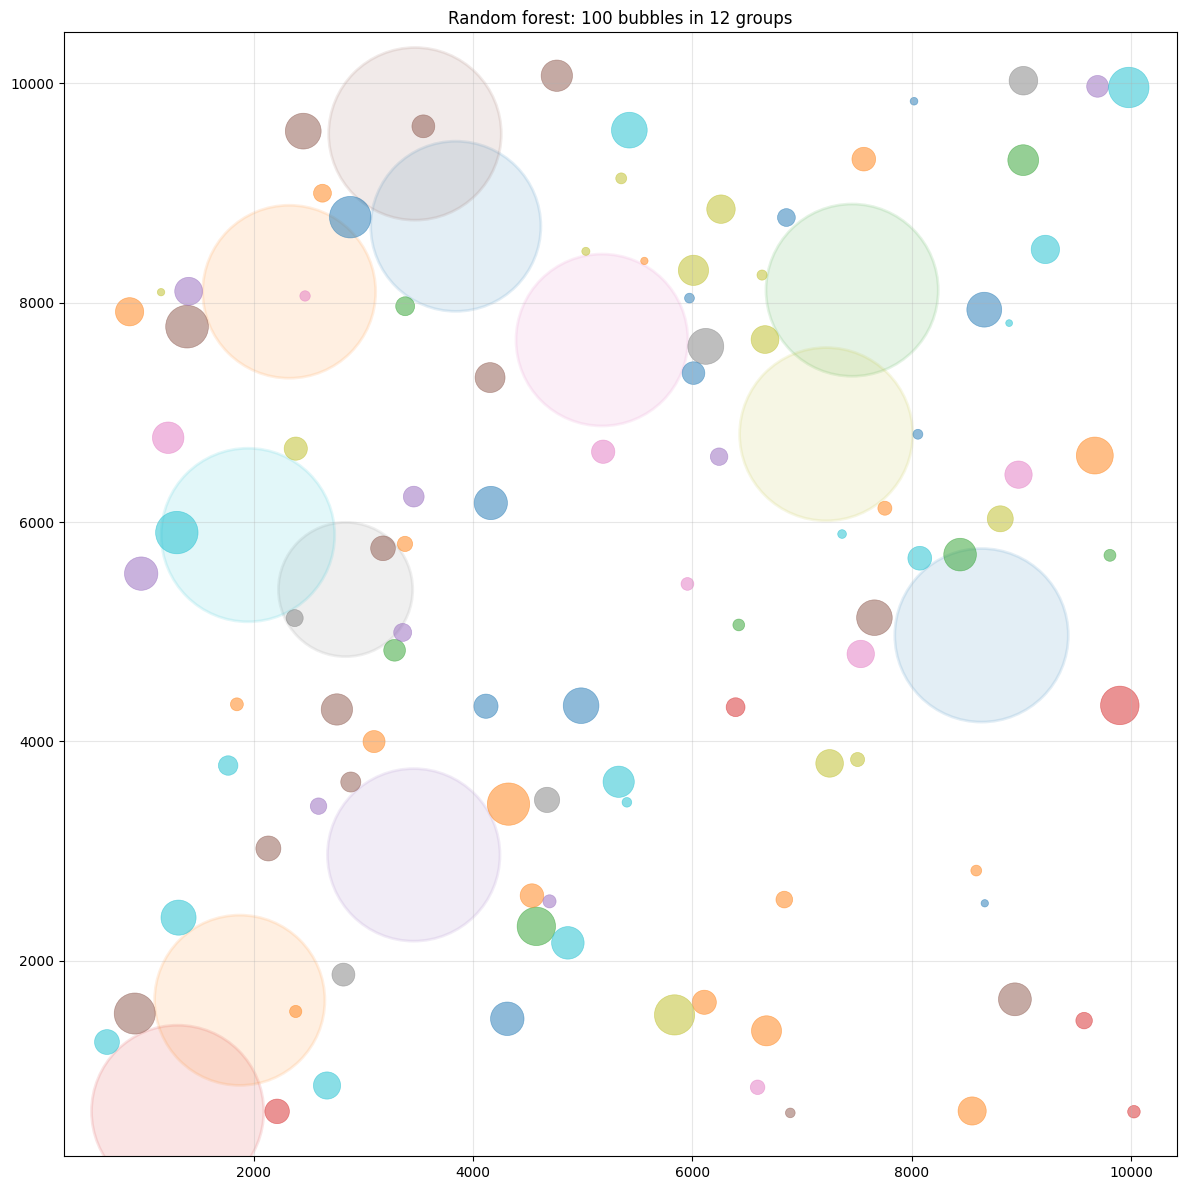

In [10]:
forest = make_random_forest(n_bubbles)

leaf_nodes = [n for n in forest.nodes if forest.out_degree(n) == 0]
group_nodes = [n for n in forest.nodes if forest.out_degree(n) > 0]
print(f"{n_bubbles} bubbles across {len(group_nodes)} groups")

pos, group_radii = nested_circles.optimize_circular_layout_with_enclosed_nodes(
    inclusion_tree=forest,
    optim_kwargs={"n_iters": 20000, "learning_rate": 0.03},
)

# Visualize
fig, ax = plt.subplots(figsize=(12, 12))
colors = plt.cm.tab10.colors

for i, root in enumerate(group_nodes):
    color = colors[i % len(colors)]
    xy = pos[root]
    r = group_radii[root]
    ax.add_patch(mpatches.Circle(xy, radius=r, color=color, alpha=0.12, ec=color, linewidth=2))

for node in leaf_nodes:
    parent = next(iter(forest.predecessors(node)))
    color = colors[group_nodes.index(parent) % len(colors)]
    xy = pos[node]
    r = forest.nodes[node]["size"]
    ax.add_patch(mpatches.Circle(xy, radius=r, color=color, alpha=0.5, ec=color, linewidth=0.5))

all_pos = list(pos.values())
max_r = max(group_radii.values())
margin = max_r * 0.5
ax.set_xlim(min(p[0] for p in all_pos) - margin, max(p[0] for p in all_pos) + margin)
ax.set_ylim(min(p[1] for p in all_pos) - margin, max(p[1] for p in all_pos) + margin)
ax.set_aspect("equal")
ax.set_title(f"Random forest: {n_bubbles} bubbles in {len(group_nodes)} groups")
ax.grid(True, alpha=0.3)
plt.tight_layout()


In [11]:
import time

n_iters = 500
sizes = [10, 50, 100, 200, 500, 1000]

# Each new n_bubbles changes array shapes, triggering JAX recompilation.
# We time two runs per size: first run (includes JIT compile) and second run (pure compute).
results = []
for n in sizes:
    times_n = []
    for run in range(2):
        forest_n = make_random_forest(n, seed=run)
        t0 = time.perf_counter()
        nested_circles.optimize_circular_layout_with_enclosed_nodes(
            inclusion_tree=forest_n,
            optim_kwargs={"n_iters": n_iters, "learning_rate": 0.1},
        )
        elapsed = time.perf_counter() - t0
        times_n.append(elapsed)
    results.append({"n": n, "compile+run": times_n[0], "run_only": times_n[1]})
    print(f"n={n:4d}  compile+run: {times_n[0]:.2f}s   run_only: {times_n[1]:.2f}s")


Iteration 0: loss = 384266.84375
Iteration 100: loss = 360797.65625
Iteration 200: loss = 341042.375
Iteration 300: loss = 322150.78125
Iteration 400: loss = 304607.5
Iteration 0: loss = 643444.0
Iteration 100: loss = 610077.625
Iteration 200: loss = 577004.875
Iteration 300: loss = 544180.25
Iteration 400: loss = 512174.90625
n=  10  compile+run: 2.72s   run_only: 0.91s
Iteration 0: loss = 16108109.0
Iteration 100: loss = 15947514.0
Iteration 200: loss = 15787803.0
Iteration 300: loss = 15628843.0
Iteration 400: loss = 15470309.0
Iteration 0: loss = 14373357.0
Iteration 100: loss = 14213649.0
Iteration 200: loss = 14055062.0
Iteration 300: loss = 13899976.0
Iteration 400: loss = 13746465.0
n=  50  compile+run: 3.01s   run_only: 0.94s
Iteration 0: loss = 65081084.0
Iteration 100: loss = 64756232.0
Iteration 200: loss = 64434380.0
Iteration 300: loss = 64112800.0
Iteration 400: loss = 63792936.0
Iteration 0: loss = 57695332.0
Iteration 100: loss = 57389112.0
Iteration 200: loss = 570856

KeyboardInterrupt: 

In [ ]:
ns = [r["n"] for r in results]
t_compile = [r["compile+run"] for r in results]
t_run = [r["run_only"] for r in results]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, yscale in zip(axes, ["linear", "log"]):
    ax.plot(ns, t_compile, "o--", label="compile + run", color="steelblue")
    ax.plot(ns, t_run, "s-", label="run only (2nd call)", color="tomato")
    ax.set_xlabel("Number of bubbles")
    ax.set_ylabel("Time (s)")
    ax.set_xscale("log")
    ax.set_yscale(yscale)
    ax.set_title(f"Scaling ({n_iters} iters) {yscale} y-axis")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()

# Fit power law on run_only times
log_n = np.log(ns)
log_t = np.log(t_run)
slope, intercept = np.polyfit(log_n, log_t, 1)
n_fit = np.linspace(min(ns), max(ns), 100)
t_fit = np.exp(intercept) * n_fit**slope
axes[1].plot(n_fit, t_fit, "k--", alpha=0.5, label=f"fit: O(n^{slope:.2f})")
axes[1].legend()

plt.suptitle(f"Bubble layout scaling random forest, {n_iters} iters per run")
plt.tight_layout()
print(f"Estimated compute complexity: O(n^{slope:.2f})")
